## Inicialización del entorno

### Configurar y montar Google Drive

In [ ]:
import sys

# Directorio actual donde se está ejecutando el notebook
ruta_base = os.getcwd()

ruta_padre = os.path.abspath(os.path.join(ruta_base, '..'))

if ruta_padre not in sys.path:
    sys.path.append(ruta_padre)

print(f"Directorio de trabajo: {ruta_base}")
print(f"Directorio padre (añadido al path): {ruta_padre}")

Directorio de trabajo: c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning
Directorio padre (añadido al path): c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1


### Importación de librerías

In [2]:
#pip install -U pymgrid
#pip install optuna
#pip install seaborn

In [3]:
import pandas as pd
import numpy as np
from pymgrid import Microgrid
from pymgrid.modules import GridModule, BatteryModule, LoadModule, RenewableModule
import random
from collections import defaultdict
import copy

from custom_env_tabular2 import CustomEnvTabular

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import os
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


### Carga y preparación de datos

In [4]:
# PRECIOS DE LA RED (Península 2025)
ruta_precios = os.path.join(ruta_padre, 'data', 'external', 'precio2025-peninsula.csv')
df_precios = pd.read_csv(ruta_precios, sep=';')
df_precios['datetime'] = pd.to_datetime(df_precios['datetime'], utc=True)
df_precios = df_precios.sort_values('datetime').reset_index(drop=True)
# Convertir de €/MWh a €/kWh
precios_kwh = df_precios['value'].values / 1000.0

# DEMANDA (LOAD) Y GENERACIÓN SOLAR (PV)
ruta_load = os.path.join(ruta_padre, 'data', 'raw', 'load', 'RefBldgFullServiceRestaurantNew2004_v1.3_7.1_6A_USA_MN_MINNEAPOLIS.csv')
ruta_pv = os.path.join(ruta_padre, 'data', 'processed', 'pv_generacion_corregida_kw.csv')

df_load = pd.read_csv(ruta_load)
df_pv = pd.read_csv(ruta_pv)

load_series = df_load.iloc[:, -1].values
pv_series = df_pv.iloc[:, -1].values

# Asegurarnos de que todas las series tienen la misma longitud
min_len = min(len(precios_kwh), len(load_series), len(pv_series), 8760)
precios_kwh = precios_kwh[:min_len]
load_series = load_series[:min_len]
pv_series = pv_series[:min_len]

print(f"Datos cargados correctamente. Longitud de las series: {min_len} horas.")

Datos cargados correctamente. Longitud de las series: 8760 horas.


### Creación de los módulos de pymgrid

In [5]:
# RED ELÉCTRICA (GridModule)
# En las versiones recientes de pymgrid, los datos de la red se pasan como un DataFrame
grid_ts = pd.DataFrame({
    'import_price': precios_kwh,
    'export_price': precios_kwh * 0.5,
    'co2_per_kwh': 0.0                 # Rellenamos con 0, pero pymgrid necesita esta columna
})

grid = GridModule(
    max_import=200.0,
    max_export=200.0,
    time_series=grid_ts
)

# BATERÍA (BatteryModule)
battery = BatteryModule(
    min_capacity=10.0,
    max_capacity=200.0,
    max_charge=50.0,
    max_discharge=50.0,
    efficiency=0.9,
    init_soc=0.5
)

# DEMANDA Y PLACAS SOLARES
load = LoadModule(time_series=load_series)
pv = RenewableModule(time_series=pv_series)

### Ensamblaje de la microrred y el entorno gymnasium

In [6]:
modules = [grid, battery, load, pv]
microrred = Microgrid(modules)

env = CustomEnvTabular(
    pymgrid_network=microrred,
    horizon=min_len,
    low_soc_threshold=0.20,   # Penalizar por debajo del 20%
    low_soc_penalty=50.0      # Penalización máxima (mayor que el beneficio de vender energía)
)

In [7]:
print(microrred.modules.keys())

KeysView({
  "load": "[LoadModule(time_series=<class 'numpy.ndarray'>, forecaster=NoForecaster, forecast_horizon=0, forecaster_increase_uncertainty=False, raise_errors=False)]",
  "renewable": "[RenewableModule(time_series=<class 'numpy.ndarray'>, raise_errors=False, forecaster=NoForecaster, forecast_horizon=0, forecaster_increase_uncertainty=False, provided_energy_name=renewable_used)]",
  "balancing": "[UnbalancedEnergyModule(raise_errors=False, loss_load_cost=10.0, overgeneration_cost=2.0)]",
  "grid": "[GridModule(max_import=200.0, max_export=200.0)]",
  "battery": "[BatteryModule(min_capacity=10.0, max_capacity=200.0, max_charge=50.0, max_discharge=50.0, efficiency=0.9, battery_cost_cycle=0.0, battery_transition_model=None, init_charge=None, init_soc=0.5, raise_errors=False)]"
})


JUSTIFICACIÓN DE LA PENALIZACIÓN DE SoC (low_soc_penalty = 50.0):
Para evitar que el agente vacíe la batería ignorando el límite del 20%, la penalización debe ser mayor que el máximo beneficio económico posible en un paso.

Cálculos del peor caso:
 - Descarga máxima de batería: 50 kW
 - Precio máximo estimado de la red: ~0.25 €/kWh
 - Beneficio máximo por vender esa energía: 50 kW * 0.25 €/kWh = +12.5 €
 
Al fijar una penalización de 50.0 (aplicada proporcionalmente), garantizamos que vaciar la batería por debajo del umbral siempre resulte en una gran pérdida económica, obligando al agente a respetar el límite de seguridad.

### Prueba de funcionamiento

In [8]:
obs, info = env.reset()
print("¡Entorno inicializado con éxito, sin errores!")
print(f"Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: {obs}")
print(f"Precio extraído para la primera hora: {info['current_import_price']:.4f} €/kWh")

¡Entorno inicializado con éxito, sin errores!
Estado Inicial Discretizado [Carga_Neta, Batería_SoC, Precio, Hora]: [2 5 3 0]
Precio extraído para la primera hora: 0.1832 €/kWh


# Funciones auxiliares

In [9]:
# 1. FUNCIÓN DE MUESTREO DE HIPERPARÁMETROS
def sample_q_params(trial):
    """Muestrea los hiperparámetros para Q-Learning Tabular."""
    return {
        "alpha": trial.suggest_float("alpha", 0.01, 0.3, log=True),
        "gamma": trial.suggest_float("gamma", 0.90, 0.999),
        "epsilon_min": 0.05
    }

In [10]:
# 2. FUNCIÓN DE EVALUACIÓN PURA (Sin exploración)
def evaluate_agent(env, Q, eval_episodes=1):
    """Evalúa la Q-Table actual (pura explotación) y devuelve el coste medio."""
    total_eval_cost = 0
    for _ in range(eval_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False
        ep_cost = 0

        while not done:
            # 1. Elegir la acción (explotación pura)
            if state in Q:
                q_values = Q[state] # Ahora es un array 1D de 9 elementos
                # .flatten() asegura que sea 1D para el choice
                best_actions = np.argwhere(q_values == np.max(q_values)).flatten()
                action = int(np.random.choice(best_actions))
            else:
                # Si no conoce el estado, escoge al azar (int del 0 al 8)
                action = int(env.action_space.sample())

            # 2. Ejecutar la acción
            next_obs, reward, terminated, truncated, info = env.step(action)
            state = tuple(next_obs)
            done = terminated or truncated
            
            ep_cost += -reward

        total_eval_cost += ep_cost

    return total_eval_cost / eval_episodes

In [11]:
GLOBAL_BEST_DIR = os.path.join(ruta_base, "Q-learning")
os.makedirs(GLOBAL_BEST_DIR, exist_ok=True)
GLOBAL_BEST_PATH = os.path.join(GLOBAL_BEST_DIR, "best_q_table_v1.pkl")
db_file_path = os.path.join(GLOBAL_BEST_DIR, "optuna_obj1.db")
DB_PATH = f"sqlite:///{db_file_path.replace(os.sep, '/')}"

# Empezamos el récord en limpio (infinito) porque es un experimento nuevo
global_best_cost = float('inf')

# Cargar el récord de este estudio concreto (por si lo pausas y lo reanudas mañana)
ESTUDIO_ACTUAL = "qlearning_obj1_bat_fisica_corregida"

try:
    study_obj1 = optuna.load_study(study_name=ESTUDIO_ACTUAL, storage=DB_PATH)
    if study_obj1.best_value < global_best_cost:
        global_best_cost = study_obj1.best_value
    print(f"Reanudando estudio {ESTUDIO_ACTUAL}. Mejor coste actual: {global_best_cost:.2f} €")
except Exception:
    print(f"Iniciando estudio {ESTUDIO_ACTUAL} desde cero en una nueva base de datos.")

Reanudando estudio qlearning_obj1_bat_fisica_corregida. Mejor coste actual: 36759.06 €


In [ ]:
# 3. FUNCIÓN OBJECTIVE CON PRUNING Y TRACKER GLOBAL
def objective(trial: optuna.Trial) -> float:
    global global_best_cost

    # 1. OBTENER HIPERPARÁMETROS
    params = sample_q_params(trial)
    alpha = params["alpha"]
    gamma = params["gamma"]
    epsilon_min = params["epsilon_min"]    

    epsilon_decay_step = 0.99996 # lo cambiamos porque hora

    # 2. Instanciar entornos LIMPIOS y AISLADOS para este trial
    # Usamos deepcopy para no alterar los módulos originales globales
    modulos_train = [copy.deepcopy(grid), copy.deepcopy(battery), copy.deepcopy(load), copy.deepcopy(pv)]
    microrred = Microgrid(modulos_train)
    env = CustomEnvTabular(
        pymgrid_network=microrred,
        horizon=min_len,
        low_soc_penalty=50.0,
        low_soc_threshold=0.20
    )
    
    modulos_eval = [copy.deepcopy(grid), copy.deepcopy(battery), copy.deepcopy(load), copy.deepcopy(pv)]
    microrred_eval = Microgrid(modulos_eval)
    eval_env = CustomEnvTabular(
        pymgrid_network=microrred_eval,
        horizon=min_len,
        low_soc_penalty=50.0,
        low_soc_threshold=0.20
    )


    # 3. Inicializar Q-Table y variables
    Q = defaultdict(lambda: np.zeros(9))
    epsilon = 1.0
    n_episodes = 10
    eval_freq = 5  # Evaluar y reportar a Optuna cada 2 episodios

    # 4. Bucle de Entrenamiento
    for ep in range(n_episodes):
        obs, info = env.reset()
        state = tuple(obs)
        done = False

        while not done:
            if random.uniform(0, 1) < epsilon:
                # sample() devuelve un np.int64, lo forzamos a int normal por seguridad
                action = int(env.action_space.sample()) 
            else:
                # Explotación: elegir mejor acción
                q_values = Q[state]
                best_actions = np.argwhere(q_values == np.max(q_values)).flatten()
                action = int(np.random.choice(best_actions))

            # ejecutar acción
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = tuple(next_obs)
            done = terminated or truncated

            # Actualizar Q-Table
            max_next_q = np.max(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * max_next_q - Q[state][action])
            
            state = next_state
            
            epsilon = max(epsilon_min, epsilon * epsilon_decay_step)
        
        # -------------------------------------------------------------------
        # REPORTE A OPTUNA Y PRUNING (EVAL_CALLBACK manual)
        # -------------------------------------------------------------------
        if (ep + 1) % eval_freq == 0:
            current_cost = evaluate_agent(eval_env, Q)

            # Reportar a Optuna el coste actual en este paso intermedio
            trial.report(current_cost, ep)

            # Comprobar si debemos cortar este trial (Pruning)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

            # Comprobar si es el mejor modelo global histórico
            if current_cost < global_best_cost:
                global_best_cost = current_cost
                
                # Guardar Q-Table de forma 100% segura (convirtiendo arrays a listas)
                q_to_save = {k: v.tolist() for k, v in Q.items()}
                with open(GLOBAL_BEST_PATH, 'wb') as f:
                    pickle.dump(q_to_save, f)
                print(f"[{trial.number}] NUEVO GLOBAL BEST: {current_cost:.2f} € → guardado en {GLOBAL_BEST_PATH}")

    # Devolver el coste final del agente entrenado
    return evaluate_agent(eval_env, Q)

# Búsqueda de mejores hiperparámetros

In [13]:
sampler = TPESampler(n_startup_trials=10)
pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=3)

study = optuna.create_study(
    study_name=ESTUDIO_ACTUAL,
    storage=DB_PATH,
    direction="minimize",
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True
)

try:
    study.optimize(objective, n_trials=30, n_jobs=1)
except KeyboardInterrupt:
    print("Búsqueda interrumpida manualmente.")

print("\nNumber of finished trials: ", len(study.trials))

# Pequeña validación por si lo paramos antes de que acabe un trial válido
if len(study.trials) > 0:
    try:
        best_trial = study.best_trial
        print(f"Best trial:\n  Coste Medio: {best_trial.value:.2f} €")
        print("  Params: ")
        for key, value in best_trial.params.items():
            print(f"    {key}: {value}")
    except ValueError:
        print("Aún no hay ningún trial completado con éxito para mostrar el mejor.")

[I 2026-03-31 20:06:03,582] A new study created in RDB with name: qlearning_obj1_bat_fisica_corregida


[0] NUEVO GLOBAL BEST: 43008.16 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning\Q-learning\best_q_table_v1.pkl
[0] NUEVO GLOBAL BEST: 40719.85 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-31 20:07:15,728] Trial 0 finished with value: 41581.47780657008 and parameters: {'alpha': 0.027644287398101347, 'gamma': 0.9518433213354858}. Best is trial 0 with value: 41581.47780657008.


[1] NUEVO GLOBAL BEST: 39933.10 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-31 20:08:22,569] Trial 1 finished with value: 38224.45373957242 and parameters: {'alpha': 0.15873824132676628, 'gamma': 0.9886153108301018}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:09:29,293] Trial 2 finished with value: 42824.64105179953 and parameters: {'alpha': 0.15174658181356512, 'gamma': 0.9898633224542759}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:10:36,187] Trial 3 finished with value: 48766.34037544794 and parameters: {'alpha': 0.0109930892285247, 'gamma': 0.9069674239410038}. Best is trial 1 with value: 38224.45373957242.


[4] NUEVO GLOBAL BEST: 38052.13 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-31 20:11:43,341] Trial 4 finished with value: 38898.09919772338 and parameters: {'alpha': 0.16248416143744185, 'gamma': 0.9540444438688943}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:12:51,402] Trial 5 finished with value: 46008.968700361256 and parameters: {'alpha': 0.06178708073713359, 'gamma': 0.9539843387707138}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:13:58,884] Trial 6 finished with value: 40549.73551032988 and parameters: {'alpha': 0.2711220692834992, 'gamma': 0.9696181281047583}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:15:05,922] Trial 7 finished with value: 44319.45199435017 and parameters: {'alpha': 0.1671883865816855, 'gamma': 0.902585139713341}. Best is trial 1 with value: 38224.45373957242.
[I 2026-03-31 20:16:14,472] Trial 8 finished with value: 38614.75282955903 and parameters: {'alpha': 0.26177563796716347, 'gamma': 0.9375801716247203}. Best is trial 1 with value: 38224.45373957242.
[I 2026

[23] NUEVO GLOBAL BEST: 35897.90 € → guardado en c:\Users\alaiu\Desktop\MASTER\3.Hiruhilekoa\Reto3_MicroRedes\OBJETIVO1\2_Q-learning\Q-learning\best_q_table_v1.pkl


[I 2026-03-31 20:26:31,284] Trial 23 finished with value: 36759.062084215664 and parameters: {'alpha': 0.2110358883242195, 'gamma': 0.9283650053102165}. Best is trial 23 with value: 36759.062084215664.
[I 2026-03-31 20:27:02,323] Trial 24 pruned. 
[I 2026-03-31 20:27:33,616] Trial 25 pruned. 
[I 2026-03-31 20:28:42,382] Trial 26 finished with value: 38768.55495532223 and parameters: {'alpha': 0.09011553257680882, 'gamma': 0.9228584675227912}. Best is trial 23 with value: 36759.062084215664.
[I 2026-03-31 20:29:13,006] Trial 27 pruned. 
[I 2026-03-31 20:29:44,158] Trial 28 pruned. 
[I 2026-03-31 20:30:15,609] Trial 29 pruned. 



Number of finished trials:  30
Best trial:
  Coste Medio: 36759.06 €
  Params: 
    alpha: 0.2110358883242195
    gamma: 0.9283650053102165


## Visualizaciones

### Funciones

In [14]:
def visualizar_comportamiento(env, Q_table, dias=3, hora_inicio=0):
    """Simula al agente durante unos días y grafica su comportamiento."""
    obs, info = env.reset()

    # 1. AVANCE RÁPIDO
    if hora_inicio > 0:
        print(f"Avanzando simulación hasta la hora {hora_inicio}...")
        for _ in range(hora_inicio):
            state = tuple(obs)
            if state in Q_table:
                best_actions = np.argwhere(Q_table[state] == np.max(Q_table[state])).flatten()
                action = int(np.random.choice(best_actions))
            else:
                action = int(env.action_space.sample())
                            
            obs, _, terminated, truncated, info = env.step(action)
            
            if terminated or truncated:
                print("Aviso: El entorno se reinició durante el avance rápido.")
                obs, info = env.reset()

    # 2. RECOPILACIÓN DE DATOS
    historial = {'soc': [], 'precio': [], 'accion_bat': [], 'accion_grid': [], 'carga_neta': []}

    # -- DATOS INICIALES (paso 0) --
    historial['soc'].append(info.get('soc', 0.5))
    # ¡TRUCO! Leemos el precio directo de la función del entorno, sin usar 'info'
    historial['precio'].append(env._get_current_import_price()) 
    historial['accion_bat'].append(4) 
    historial['accion_grid'].append(1) 
    # Usamos la clave que SÍ tienes en tu entorno actual
    historial['carga_neta'].append(info.get('net_load_kw', 0)) 

    for step in range(dias * 24):
        state = tuple(obs)
        if state in Q_table:
            best_actions = np.argwhere(Q_table[state] == np.max(Q_table[state])).flatten()
            action = best_actions[np.random.choice(len(best_actions))]
        else:
            action = env.action_space.sample()

        action_step = tuple(action) if hasattr(action, '__iter__') else action
        obs, _, terminated, truncated, info = env.step(action_step)

        # -- GUARDAMOS MÉTRICAS DEL PASO ACTUAL --
        historial['soc'].append(info.get('soc', 0))
        # ¡TRUCO! Volvemos a leer el precio directo del entorno
        historial['precio'].append(env._get_current_import_price())
        historial['accion_bat'].append(action) 
        # Usamos la clave que SÍ tienes
        historial['carga_neta'].append(info.get('net_load_kw', 0))
        
        # Deducimos la acción de la red a partir del balance que SÍ tienes en info
        balance_red = info.get('grid_balance_kw', 0)
        if balance_red > 0.01:
            accion_grid = 0 # Importa
        elif balance_red < -0.01:
            accion_grid = 2 # Exporta
        else:
            accion_grid = 1 # Neutro
        historial['accion_grid'].append(accion_grid)

        if terminated or truncated:
            obs, info = env.reset()

    # 3. DIBUJAR GRÁFICAS
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(5, 1, figsize=(14, 15), sharex=True)

    axs[0].plot(historial['precio'], color='red', label='Precio Importación (€/kWh)')
    axs[0].set_ylabel('€/kWh'); axs[0].legend(); axs[0].grid(True)
    axs[0].set_title(f'Comportamiento de la Microrred (Inicio: hora {hora_inicio}, Duración: {dias} días)')

    axs[1].plot(historial['carga_neta'], color='orange', label='Carga Neta (kW)')
    axs[1].axhline(0, color='black', linestyle='--')
    axs[1].set_ylabel('kW'); axs[1].legend(); axs[1].grid(True)

    axs[2].plot(historial['soc'], color='blue', label='Nivel de Batería (SoC)')
    axs[2].set_ylabel('SoC (0 a 1)'); axs[2].legend(); axs[2].grid(True)
    axs[2].set_ylim(0, 1) 

    axs[3].scatter(range(len(historial['accion_bat'])), historial['accion_bat'], color='green', label='Batería (0=Descarga Max, 4=Neutro, 8=Carga Max)', s=15)
    axs[3].set_yticks(range(9)); axs[3].set_ylabel('Acción Bat'); axs[3].legend(); axs[3].grid(True)

    axs[4].scatter(range(len(historial['accion_grid'])), historial['accion_grid'], color='purple', label='Red (0=Import, 1=Neutro, 2=Export)', s=15)
    axs[4].set_yticks(range(3)); axs[4].set_ylabel('Acción Red'); axs[4].legend(); axs[4].grid(True)
    axs[4].set_xlabel('Horas Simuladas')

    plt.tight_layout()
    plt.show()
def visualizar_exploracion(Q_table):
    """Muestra qué estados (SoC y Hora) ha explorado el agente."""
    visitas = np.zeros((11, 24))
    
    for estado in Q_table.keys():
        soc = int(estado[1]) 
        hora = int(estado[3])
        # Verificación de seguridad para evitar IndexError
        if 0 <= soc < 11 and 0 <= hora < 24:
            visitas[soc, hora] += 1

    plt.figure(figsize=(10, 6))
    sns.heatmap(visitas, cmap="Blues", yticklabels=[f"{i*10}%" for i in range(11)])
    plt.gca().invert_yaxis()
    plt.title("Mapa de Calor de Exploración: Combinaciones SoC-Hora descubiertas")
    plt.xlabel("Hora del Día (0-23)"); plt.ylabel("Nivel de Batería (SoC)")
    plt.show()

def visualizar_politica(Q_table, precio_fijo=2, carga_fija=2):
    """Muestra la política (acción Batería) para un escenario específico."""
    politica_bat = np.full((11, 24), np.nan)

    for estado, q_values in Q_table.items():
        # Validamos que el estado coincida con las condiciones de contorno
        if estado[0] == carga_fija and estado[2] == precio_fijo:
            soc = int(estado[1])
            hora = int(estado[3])
            
            if 0 <= soc < 11 and 0 <= hora < 24:
                best_action = np.argwhere(q_values == np.max(q_values))[0]
                politica_bat[soc, hora] = best_action[0] # Acción de la batería

    plt.figure(figsize=(10, 6))
    # Usamos un mapa de colores divergente y forzamos límites de 0 a 8
    sns.heatmap(politica_bat, cmap=sns.color_palette("coolwarm", 9), vmin=0, vmax=8, 
                yticklabels=[f"{i*10}%" for i in range(11)], annot=True, cbar_kws={'label': 'Acción Batería'})
    plt.gca().invert_yaxis()
    plt.title(f"Política Óptima BATERÍA (Precio Discretizado={precio_fijo}, Demanda={carga_fija})")
    plt.xlabel("Hora del Día (0-23)"); plt.ylabel("Nivel de Batería (SoC)")
    plt.show()

¡Cerebro cargado con éxito! Estados aprendidos: 2051
Avanzando simulación hasta la hora 4320...


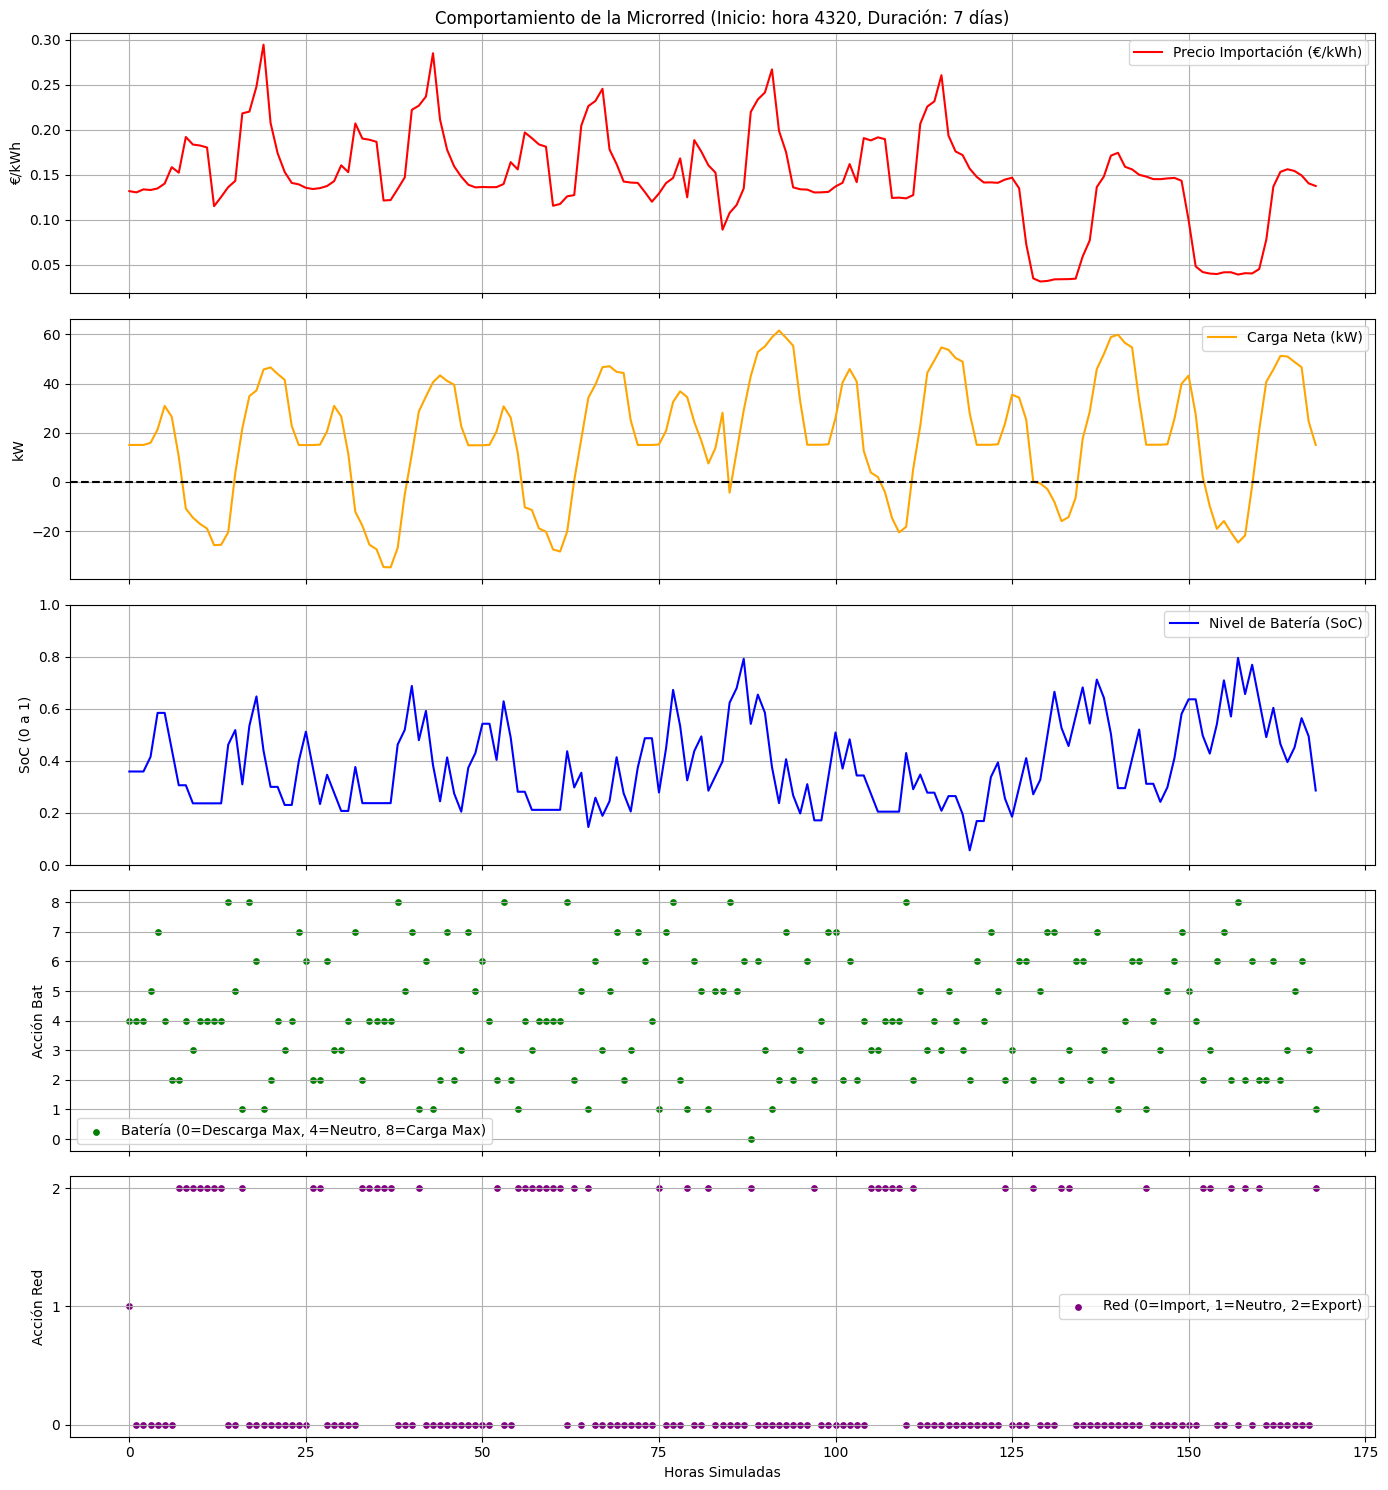

In [15]:
# ==============================================================================
# 2. CARGA DEL MEJOR AGENTE Y VISUALIZACIÓN
# ==============================================================================

# 1. Cargar el cerebro (Q-Table) del disco duro
if os.path.exists(GLOBAL_BEST_PATH):
    with open(GLOBAL_BEST_PATH, 'rb') as f:
        Q_ganadora = pickle.load(f)
    print(f"¡Cerebro cargado con éxito! Estados aprendidos: {len(Q_ganadora)}")
else:
    print(f"Error: No se ha encontrado el archivo {GLOBAL_BEST_PATH}. ¡Entrena primero!")

# 2. Instanciar un entorno limpio para la evaluación
microrred_eval = Microgrid([grid, battery, load, pv])
env_eval = CustomEnvTabular(
    pymgrid_network=microrred_eval, 
    horizon=min_len, 
    low_soc_penalty=50.0, 
    low_soc_threshold=0.20
)

# 3. LÁNZAR LAS VISUALIZACIONES
# Descomenta las que quieras ver

# Ver 3 días de comportamiento simulado:
visualizar_comportamiento(env_eval, Q_ganadora, dias=7, hora_inicio=4320)

# Ver el mapa de calor de exploración (qué estados conoce):
# visualizar_exploracion(Q_ganadora)

# Ver el mapa de decisiones fijando un precio (ej: 2) y demanda (ej: 2):
# visualizar_politica(Q_ganadora, precio_fijo=2, carga_fija=2)

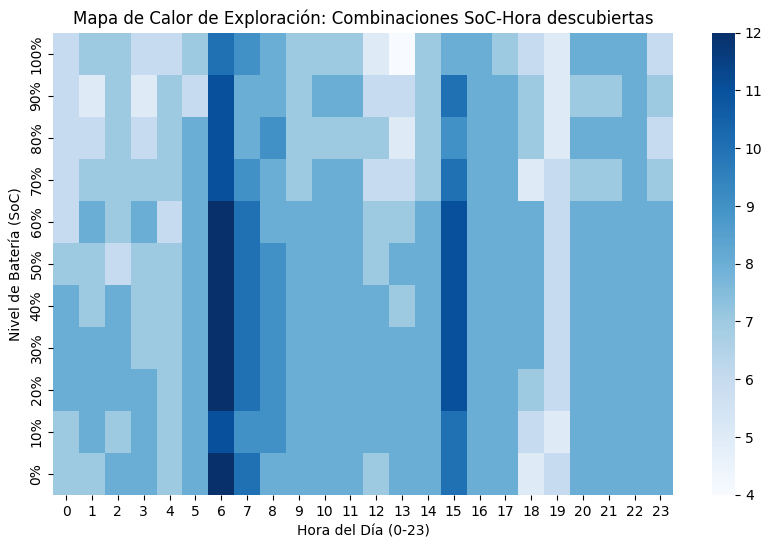

In [16]:
visualizar_exploracion(Q_ganadora)

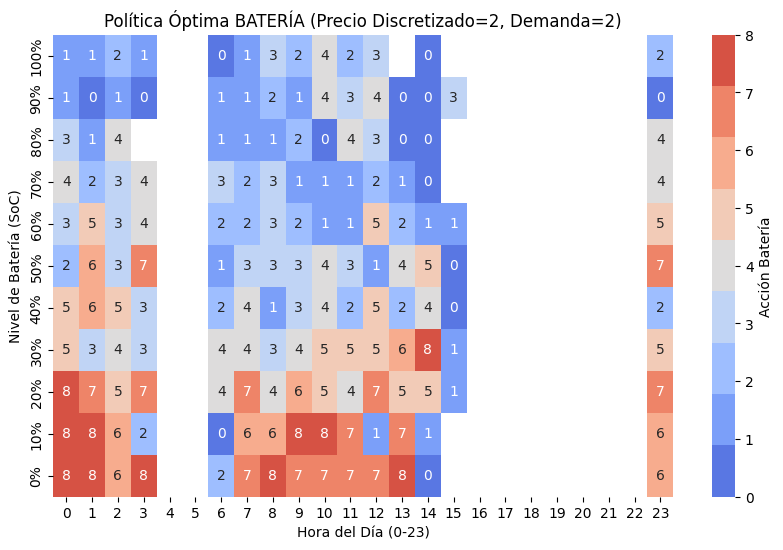

In [17]:
visualizar_politica(Q_ganadora, precio_fijo=2, carga_fija=2)

# Entrenamiento

In [20]:
import time

NUM_RUNS = 30
NUM_EPISODES = 15 # En el hp search hemos puesto 10, esto podríamos probar con 20

# 1. Recuperar los mejores hiperparámetros de Optunaprint("\n--- Extrayendo mejores hiperparámetros de Optuna ---")
try:
    best_params = study.best_trial.params
    alpha = best_params["alpha"]
    gamma = best_params["gamma"]
    epsilon_min = best_params.get("epsilon_min", 0.05) # lo hemos definido fijo
    print(f"Usando hiperparámetros óptimos: alpha={alpha:.4f}, gamma={gamma:.4f}, epsilon_min={epsilon_min}")
except Exception as e:
    print("Aviso: No se pudieron extraer los parámetros. Usando valores por defecto.")
    alpha, gamma, epsilon_min = 0.1, 0.99, 0.05

total_steps_per_run = min_len * (NUM_EPISODES * 0.85)
epsilon_decay_step = (epsilon_min / 1.0) ** (1 / total_steps_per_run)   
print(f" Epsilon decay calculado: {epsilon_decay_step:.6f}")

# Matriz para guardar los costes:
q_learning_costs_matrix = np.zeros((NUM_RUNS, NUM_EPISODES))

# DIRECTORIO NUEVO: Para no sobrescribir nada de Optuna ni tu best_q_table_v1.pkl
RESULTADOS_ENTRENAMIENTO_DIR = os.path.join(ruta_base, "Resultados_Entrenamiento_Q")
os.makedirs(RESULTADOS_ENTRENAMIENTO_DIR, exist_ok=True)

print("\n INICIANDO ENTRENAMIENTO DEFINITIVO MULTI-RUN PARA ANÁLISIS ESTADÍSTICO...")
start_time_global = time.time()

for run in range(NUM_RUNS):
    print(f"\n--- Iniciando Run {run + 1}/{NUM_RUNS} ---")
    
    # A. FIJAR SEMILLAS PARA GARANTIZAR REPRODUCIBILIDAD
    np.random.seed(run)
    random.seed(run)
    
    # B. CREAR UN ENTORNO TOTALMENTE LIMPIO
    modulos_run = [copy.deepcopy(grid), copy.deepcopy(battery), copy.deepcopy(load), copy.deepcopy(pv)]
    microrred_run = Microgrid(modulos_run)
    env_run = CustomEnvTabular(
        pymgrid_network=microrred_run,
        horizon=min_len,
        low_soc_penalty=50.0,
        low_soc_threshold=0.20
    )

    env_run.action_space.seed(run)
    
    # C. INICIALIZAR PARÁMETROS (Q-TABLE) Y EXPLORACIÓN DESDE CERO
    Q = defaultdict(lambda: np.zeros(9))
    epsilon = 1.0
    
    # D. BUCLE DE ENTRENAMIENTO (EPISODIOS)
    for ep in range(NUM_EPISODES):
        obs, info = env_run.reset()
        state = tuple(obs)
        done = False
        
        ep_cost = 0 # Corte real en EUROS
        
        while not done:
            # Exploración
            if random.uniform(0, 1) < epsilon:
                action = int(env_run.action_space.sample())
            else:
                q_values = Q[state]
                best_actions = np.argwhere(q_values == np.max(q_values)).flatten()
                action = int(np.random.choice(best_actions))

            # Ejecutar paso
            next_obs, reward, terminated, truncated, info = env_run.step(action)
            next_state = tuple(next_obs)
            done = terminated or truncated

            # ACTUALIZACIÓN DEL CEREBRO (Usa 'reward' que incluye las penalizaciones SOC)            
            max_next_q = np.max(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * max_next_q - Q[state][action])
            
            state = next_state
            
            # Acumulamos el coste económico REAL para el análisis estadístico
            ep_cost += info["cost_eur"]
            
            # Decaimiento de epsilon
            epsilon = max(epsilon_min, epsilon * epsilon_decay_step)
        
        # Guardamos el coste total del episodio en la matriz
        q_learning_costs_matrix[run, ep] = ep_cost
        
        print(f"  Episodio {ep + 1}/{NUM_EPISODES} | Coste Total: {ep_cost:.2f} € | Epsilon final: {epsilon:.4f}")

    # E. GUARDAR LA Q-TABLE DE ESTE RUN INDEPENDIENTE
    q_to_save = {k: v.tolist() for k, v in Q.items()}
    run_q_path = os.path.join(RESULTADOS_ENTRENAMIENTO_DIR, f"q_table_run_{run}.pkl")
    with open(run_q_path, 'wb') as f:
        pickle.dump(q_to_save, f)
    print(f" Q-Table del Run {run + 1} guardada con éxito.")

# 3. GUARDAR LA MATRIZ FINAL DE COSTES PARA EL FUTURO ANÁLISIS ESTADÍSTICO
matriz_path = os.path.join(RESULTADOS_ENTRENAMIENTO_DIR, "q_learning_costs_matrix.npy")
np.save(matriz_path, q_learning_costs_matrix)

print(f"\nEntrenamiento multi-run finalizado en {(time.time() - start_time_global)/60:.2f} minutos.")
print(f"La matriz de costes se ha guardado en:\n{matriz_path}")

Aviso: No se pudieron extraer los parámetros. Usando valores por defecto.
 Epsilon decay calculado: 0.999973

 INICIANDO ENTRENAMIENTO DEFINITIVO MULTI-RUN PARA ANÁLISIS ESTADÍSTICO...

--- Iniciando Run 1/30 ---
  Episodio 1/15 | Coste Total: 389013.55 € | Epsilon final: 0.7906
  Episodio 2/15 | Coste Total: 328697.94 € | Epsilon final: 0.6251
  Episodio 3/15 | Coste Total: 240026.08 € | Epsilon final: 0.4942
  Episodio 4/15 | Coste Total: 155656.75 € | Epsilon final: 0.3907
  Episodio 5/15 | Coste Total: 122736.98 € | Epsilon final: 0.3089
  Episodio 6/15 | Coste Total: 88257.64 € | Epsilon final: 0.2442
  Episodio 7/15 | Coste Total: 72727.21 € | Epsilon final: 0.1931
  Episodio 8/15 | Coste Total: 63395.76 € | Epsilon final: 0.1527
  Episodio 9/15 | Coste Total: 54032.04 € | Epsilon final: 0.1207
  Episodio 10/15 | Coste Total: 47608.22 € | Epsilon final: 0.0954
  Episodio 11/15 | Coste Total: 44115.06 € | Epsilon final: 0.0755
  Episodio 12/15 | Coste Total: 43283.85 € | Epsilon f